# **Feature Transformations**
### **Purpose of Transformation**
 - 1. Reduce Skewness 
 - 2. Handle Outliers
### **Methods:**
- 1. Log Transformation
- 2. Box-cox / Yeo-Johnson
### **Outliers:**
- Exreme values that lie far from the main data distribution & can negatively affect machine learning model performance.
### **Methods:**
- 1. Clipping
- 2. Winsorization
------------------------------

# 1. Import & Load Dataset

In [6]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load dataset - telecom churn
df = pd.read_csv("../datasets/telecom_churn.csv")

# display dataset
df.head()

,customer_id,signup_date,age,gender,city,education_level,employment_status,monthly_income,monthly_bill,internet_usage_gb,call_minutes,contract_type,support_tickets,customer_feedback,churn
0,10001,2019-01-01,65,Male,Multan,Bachelor,Employed,57643.0,10049.0,5.8,52.0,6-Month,1,Coverage is poor in my location,0
1,10002,2019-01-02,22,Female,Peshawar,Master,Employed,18207.0,2752.0,11.9,22.0,6-Month,2,Billing issues occurred multiple times,0
2,10003,2019-01-03,43,Male,Gujranwala,Secondary,Employed,13075.0,3155.0,40.0,87.0,Monthly,0,Billing issues occurred multiple times,0
3,10004,2019-01-04,21,Male,Lahore,Secondary,Employed,38890.0,5859.0,8.5,147.0,6-Month,2,Customer support was helpful,0
4,10005,2019-01-05,37,Female,Hyderabad,Primary,Employed,17475.0,5106.0,3.3,183.0,12-Month,0,Coverage is poor in my location,0


# 2. See the Problem

In [7]:
# display stat.
df[["monthly_income", "monthly_bill"]].describe()

,monthly_income,monthly_bill
count,1200.000000,1200.000000
mean,31155.975833,5939.150833
std,19351.937726,4046.473963
min,4984.000000,710.000000
25%,17795.000000,3291.750000
50%,26628.000000,4871.000000
75%,39886.250000,7485.500000
max,209790.000000,36361.000000


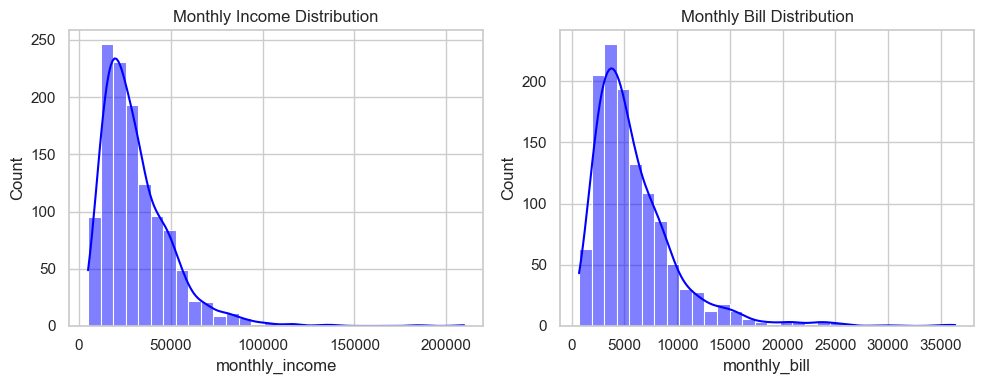

In [12]:
# Histogram to check skewness
sns.set(style = "whitegrid")
plt.figure(figsize = (10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df["monthly_income"], kde = True, bins = 30, color = "blue")
plt.title("Monthly Income Distribution")

plt.subplot(1, 2, 2)
sns.histplot(df["monthly_bill"], kde = True, bins = 30, color = "blue")
plt.title("Monthly Bill Distribution")
plt.tight_layout()

plt.show()

### This shows:
- Max > Mean
- Strong Skew present
- Ideal candidate for transformation

# 3. Log Transformation

In [15]:
df["income_log"] = np.log1p(df["monthly_income"])
df[["monthly_income", "income_log"]].head()

,monthly_income,income_log
0,57643.0,10.962041
1,18207.0,9.809616
2,13075.0,9.478534
3,38890.0,10.568518
4,17475.0,9.768584
